## Import Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import files

In [ ]:
sns.set_style("whitegrid")

blue_palette = sns.color_palette("Blues", 10)

## Load Dataset

In [ ]:
uploaded = files.upload()
df = pd.read_excel("Dataset Narkotika.xlsx")
df.head()

Saving Dataset Narkotika.xlsx to Dataset Narkotika.xlsx


,tahun,kasus_shabu,kasus_ganja,kasus_ekstasi,kasus_tembakau_gorilla,tersangka_shabu,tersangka_ganja,tersangka_ekstasi,tersangka_tembakau_sintetis,tersangka_laki_laki,...,Mengurus_Rumah_Tangga,BUMN_DPRD,Lainnya,Tidak_Lulus_SD,SD,SMP,SLTA,Perguruan_Tinggi,pengedar,pengguna
0,2013,2,0,0,0,4,0,0,0,4,...,0,0,0,0,0,0,4,0,1,3
1,2014,5,1,0,0,6,1,0,0,5,...,0,0,1,0,0,0,6,1,3,4
2,2015,8,0,0,0,13,0,0,0,13,...,0,0,0,0,0,2,10,1,2,11
3,2016,17,0,0,0,28,0,0,0,25,...,2,0,1,0,1,2,15,10,16,12
4,2017,19,3,0,0,25,5,0,0,29,...,1,0,2,0,1,3,23,3,29,1


# Preprocessing Data

## Definisi Kelompok Kolom

In [ ]:
jenis_narkotika_cols = [
"kasus_shabu",
"kasus_ganja",
"kasus_ekstasi",
"kasus_tembakau_gorilla"
]

umur_cols = [
"umur_<18",
"umur_18_40",
"umur_>40"
]

pendidikan_cols = [
"Tidak_Lulus_SD",
"SD",
"SMP",
"SLTA",
"Perguruan_Tinggi"
]

pekerjaan_cols = [
"PNS","TNI","POLRI","Swasta","Wiraswasta","Petani",
"Pelajar_Mahasiswa","Buruh","Belum_Tidak_Bekerja",
"Mengurus_Rumah_Tangga","BUMN_DPRD","Lainnya"
]

## Melihat Struktur Data

In [ ]:
# Melihat Struktur Data
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   tahun                        13 non-null     int64
 1   kasus_shabu                  13 non-null     int64
 2   kasus_ganja                  13 non-null     int64
 3   kasus_ekstasi                13 non-null     int64
 4   kasus_tembakau_gorilla       13 non-null     int64
 5   tersangka_shabu              13 non-null     int64
 6   tersangka_ganja              13 non-null     int64
 7   tersangka_ekstasi            13 non-null     int64
 8   tersangka_tembakau_sintetis  13 non-null     int64
 9   tersangka_laki_laki          13 non-null     int64
 10  tersangka_perempuan          13 non-null     int64
 11  umur_<18                     13 non-null     int64
 12  umur_18_40                   13 non-null     int64
 13  umur_>40                     13 non-null     int64
 

## Missing Value Checking

In [ ]:
# Melihat Missing Value
print(df.isnull().sum())

tahun                          0
kasus_shabu                    0
kasus_ganja                    0
kasus_ekstasi                  0
kasus_tembakau_gorilla         0
tersangka_shabu                0
tersangka_ganja                0
tersangka_ekstasi              0
tersangka_tembakau_sintetis    0
tersangka_laki_laki            0
tersangka_perempuan            0
umur_<18                       0
umur_18_40                     0
umur_>40                       0
PNS                            0
TNI                            0
POLRI                          0
Swasta                         0
Wiraswasta                     0
Petani                         0
Pelajar_Mahasiswa              0
Buruh                          0
Belum_Tidak_Bekerja            0
Mengurus_Rumah_Tangga          0
BUMN_DPRD                      0
Lainnya                        0
Tidak_Lulus_SD                 0
SD                             0
SMP                            0
SLTA                           0
Perguruan_

## Feature Engineering

In [ ]:
# Feature Engineering
df["total_kasus"] = (
    df["kasus_shabu"] +
    df["kasus_ganja"] +
    df["kasus_ekstasi"] +
    df["kasus_tembakau_gorilla"]
)

# Data Understanding

## Ringkasan Dataset

In [ ]:
# Ringkasan Dataset
jenis_narkotika = df[jenis_narkotika_cols].sum()
umur = df[umur_cols].sum()
pendidikan = df[pendidikan_cols].sum()
pekerjaan = df[pekerjaan_cols].sum()
peran = df[["pengedar","pengguna"]].sum()

print("===== PROFIL TERSANGKA =====")
print("Jenis narkotika dominan:", jenis_narkotika.idxmax())
print("Kelompok umur dominan:", umur.idxmax())
print("Pekerjaan dominan:", pekerjaan.idxmax())
print("Pendidikan dominan:", pendidikan.idxmax())
print("Peran tersangka dominan:", peran.idxmax())
print("\nJumlah tahun data:", len(df))
print("Rata-rata kasus per tahun:", round(df["total_kasus"].mean(),2))
print("Kasus tertinggi:", df["total_kasus"].max())
print("Kasus terendah:", df["total_kasus"].min())

===== PROFIL TERSANGKA =====
Jenis narkotika dominan: kasus_shabu
Kelompok umur dominan: umur_18_40
Pekerjaan dominan: Swasta
Pendidikan dominan: SLTA
Peran tersangka dominan: pengedar

Jumlah tahun data: 13
Rata-rata kasus per tahun: 17.85
Kasus tertinggi: 33
Kasus terendah: 2


## Insight Data

### Analysis Jenis Narkotika

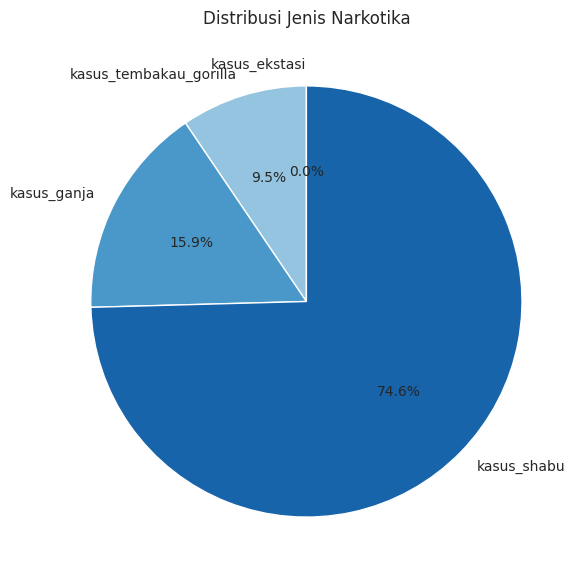

Jenis narkotika terbanyak: kasus_shabu


In [ ]:
jenis_narkotika = df[
["kasus_shabu","kasus_ganja","kasus_ekstasi","kasus_tembakau_gorilla"]
].sum()

# urutkan dari kecil ke besar
jenis_narkotika = jenis_narkotika.sort_values()

# buat warna gradasi biru
colors = sns.color_palette("Blues", len(jenis_narkotika))

plt.figure(figsize=(7,7))

plt.pie(
    jenis_narkotika,
    labels=jenis_narkotika.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title("Distribusi Jenis Narkotika")

plt.show()

jenis_narkotika = df[jenis_narkotika_cols].sum()

print("Jenis narkotika terbanyak:", jenis_narkotika.idxmax())

In [ ]:
jenis_narkotika = df[jenis_narkotika_cols].sum()

print("Jenis narkotika terbanyak:", jenis_narkotika.idxmax())

Jenis narkotika terbanyak: kasus_shabu


### Analysis Gender Tersangka

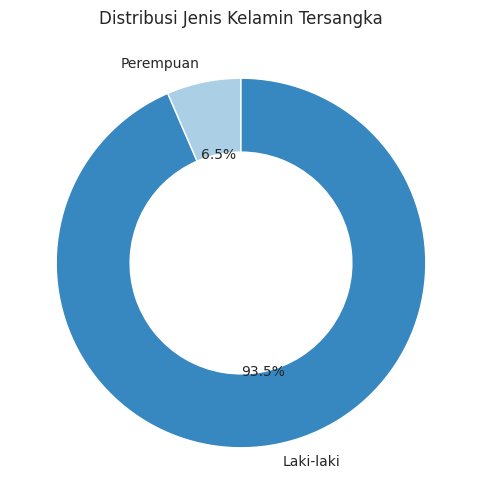

In [ ]:
gender = df[
["tersangka_laki_laki","tersangka_perempuan"]
].sum()

# rapikan label
gender.index = ["Laki-laki","Perempuan"]

# urutkan dari kecil ke besar
gender = gender.sort_values()

# warna gradasi biru
colors = sns.color_palette("Blues", len(gender))

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Distribusi Jenis Kelamin Tersangka")

plt.show()

### Analysis Umur Tersangka

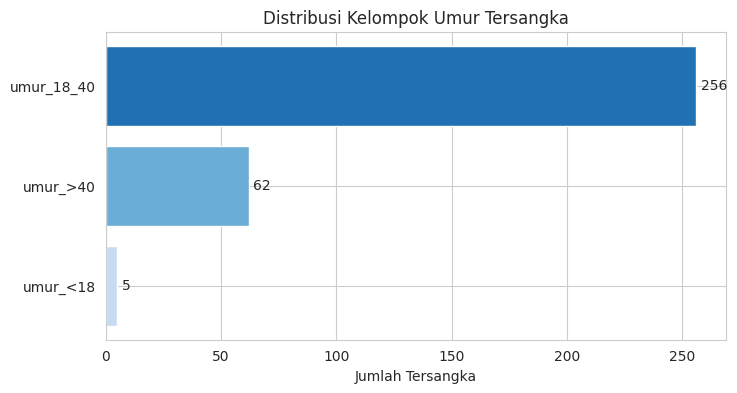

In [ ]:
umur = df[
["umur_<18","umur_18_40","umur_>40"]
].sum().sort_values()

colors = sns.color_palette("Blues", len(umur))

plt.figure(figsize=(8,4))

bars = plt.barh(
    umur.index,
    umur.values,
    color=colors
)

for i, v in enumerate(umur.values):
    plt.text(v + 2, i, str(v), va='center')

plt.title("Distribusi Kelompok Umur Tersangka")
plt.xlabel("Jumlah Tersangka")

plt.show()

In [ ]:
umur = df[umur_cols].sum()

print("Kelompok umur dominan:", umur.idxmax())

Kelompok umur dominan: umur_18_40


### Analysis Pekerjaan Tersangka

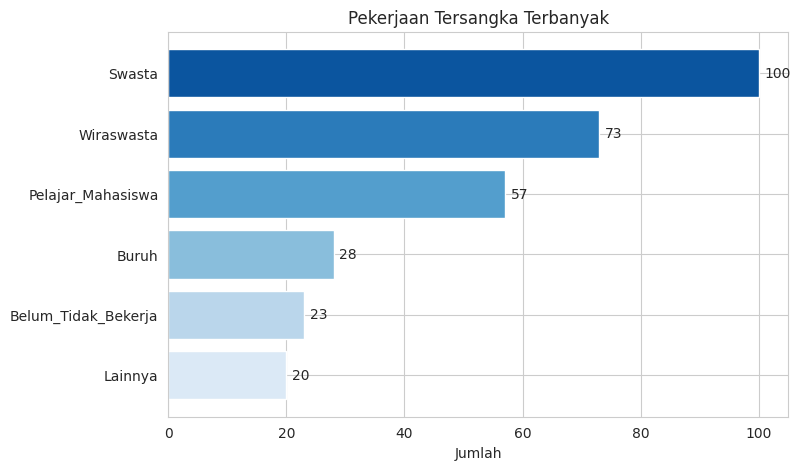

In [ ]:
pekerjaan = df[pekerjaan_cols].sum().sort_values()

top_pekerjaan = pekerjaan.tail(6)

colors = sns.color_palette("Blues", len(top_pekerjaan))

plt.figure(figsize=(8,5))

bars = plt.barh(
    top_pekerjaan.index,
    top_pekerjaan.values,
    color=colors
)

for i, v in enumerate(top_pekerjaan.values):
    plt.text(v + 1, i, str(v), va='center')

plt.title("Pekerjaan Tersangka Terbanyak")
plt.xlabel("Jumlah")

plt.show()

In [ ]:
pekerjaan = df[pekerjaan_cols].sum()

print("Pekerjaan dominan:", pekerjaan.idxmax())

top_pekerjaan = pekerjaan.sort_values(ascending=False)

print("\nTop pekerjaan tersangka:")
print(top_pekerjaan.head())

Pekerjaan dominan: Swasta

Top pekerjaan tersangka:
Swasta                 100
Wiraswasta              73
Pelajar_Mahasiswa       57
Buruh                   28
Belum_Tidak_Bekerja     23
dtype: int64


### Analysis Pendidikan Tersangka

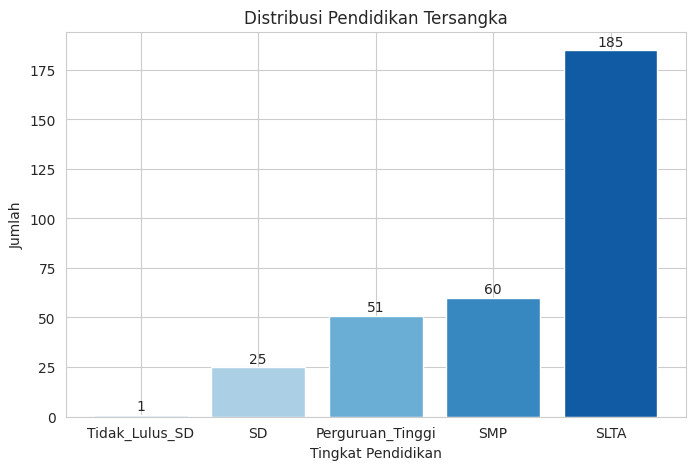

In [ ]:
pendidikan = df[
["Tidak_Lulus_SD","SD","SMP","SLTA","Perguruan_Tinggi"]
].sum().sort_values()

colors = sns.color_palette("Blues", len(pendidikan))

plt.figure(figsize=(8,5))

bars = plt.bar(
    pendidikan.index,
    pendidikan.values,
    color=colors
)

for i, v in enumerate(pendidikan.values):
    plt.text(i, v + 2, str(v), ha='center')

plt.title("Distribusi Pendidikan Tersangka")
plt.xlabel("Tingkat Pendidikan")
plt.ylabel("Jumlah")

plt.show()

In [ ]:
pendidikan = df[pendidikan_cols].sum()

print("Pendidikan dominan:", pendidikan.idxmax())

Pendidikan dominan: SLTA


### Analysis Peran Tersangka

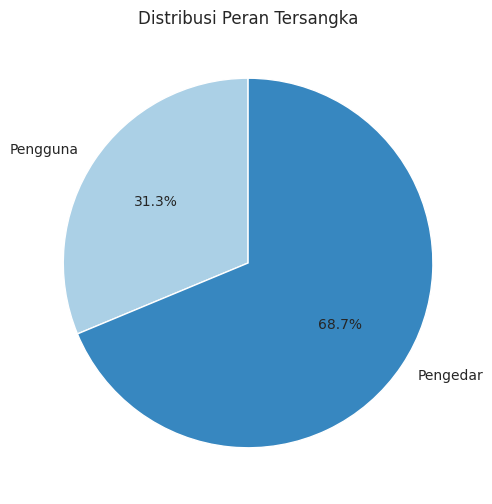

In [ ]:
peran = df[
["pengedar","pengguna"]
].sum()

peran.index = ["Pengedar","Pengguna"]

# urutkan supaya kecil → besar
peran = peran.sort_values()

colors = sns.color_palette("Blues", len(peran))

plt.figure(figsize=(6,6))

plt.pie(
    peran,
    labels=peran.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90
)

plt.title("Distribusi Peran Tersangka")

plt.show()

In [ ]:
peran = df[["pengedar","pengguna"]].sum()

print("Peran tersangka dominan:", peran.idxmax())

Peran tersangka dominan: pengedar


## Visualisasi Tren Kasus

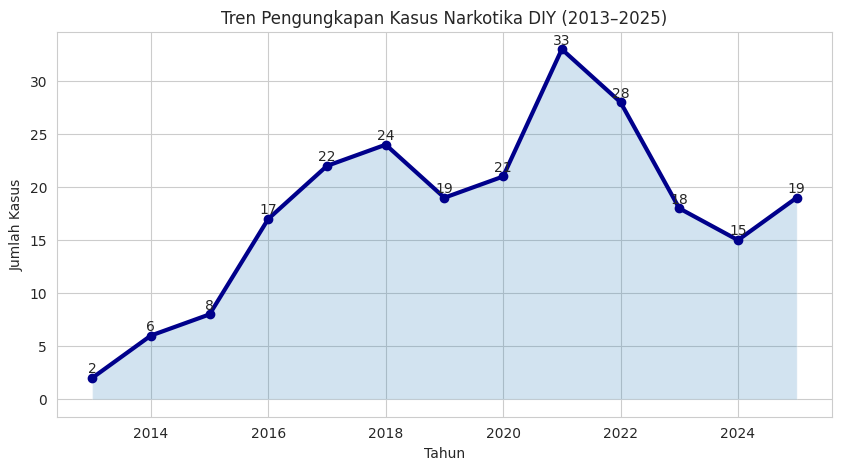

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

plt.plot(
df["tahun"],
df["total_kasus"],
marker="o",
linewidth=3,
color="darkblue"
)

plt.fill_between(
df["tahun"],
df["total_kasus"],
alpha=0.2
)

for i, v in enumerate(df["total_kasus"]):
    plt.text(df["tahun"][i], v+0.5, str(v), ha='center')

plt.title("Tren Pengungkapan Kasus Narkotika DIY (2013–2025)")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Kasus")

plt.show()

# Time Series

## Persiapan Time Series

In [ ]:
ts = df[["tahun","total_kasus"]]

ts = ts.set_index("tahun")

print(ts)

       total_kasus
tahun             
2013             2
2014             6
2015             8
2016            17
2017            22
2018            24
2019            19
2020            21
2021            33
2022            28
2023            18
2024            15
2025            19


## Uji Stasioneritas (ADF Test)

In [ ]:
result = adfuller(ts["total_kasus"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.36649233234965
p-value: 0.15141784535873032


ARIMA memiliki syarat data harus stasioner yang di buktikan dengan ADF Test, hasilnya harus p-value < 0.05

Karena hasil ADF Test didapat 0.15 yang mana ini 0.15 > 0.05 maka data ini dinyatakan tidak stasioner dan harus dilakukan differencing

## Differencing

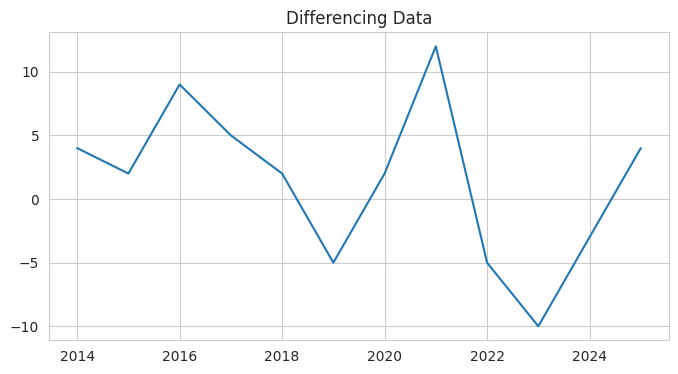

ADF Statistic: -0.19577666170844477
p-value: 0.9390231593308304


In [ ]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(8,4))
plt.plot(ts_diff)
plt.title("Differencing Data")
plt.show()

result = adfuller(ts_diff["total_kasus"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

Karena hasil diff 1 masih menghasilkan p-value: 0.939 > 0.05, maka kita lakukakn lagi diff 2

In [ ]:
ts_diff2 = ts_diff.diff().dropna()

result = adfuller(ts_diff2["total_kasus"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -6.590385270315267
p-value: 7.139085788235902e-09


Hasil diff 2 p-value: 0.000000007139 < 0.05, disini syarat stasioner terpenuhi

Tetapi karena data saya hanya 13 jika digunakan diff 2, maka ada 11 data yang bisa di gunakan yang mana ini sangat sedikit, sehingga saya akan menguji beberapa model agar melihat hasil yang terbaik

## Plot ACF & PACF

<Figure size 1000x400 with 0 Axes>

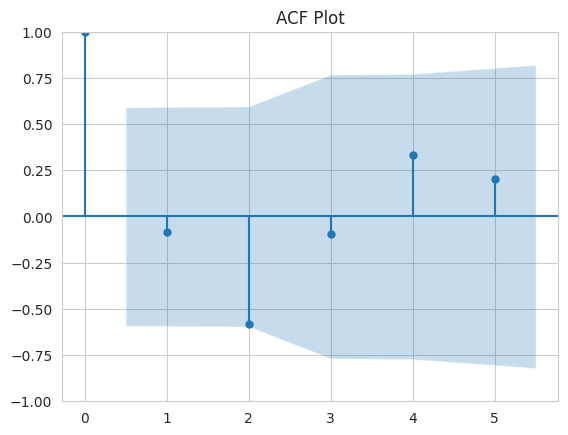

<Figure size 1000x400 with 0 Axes>

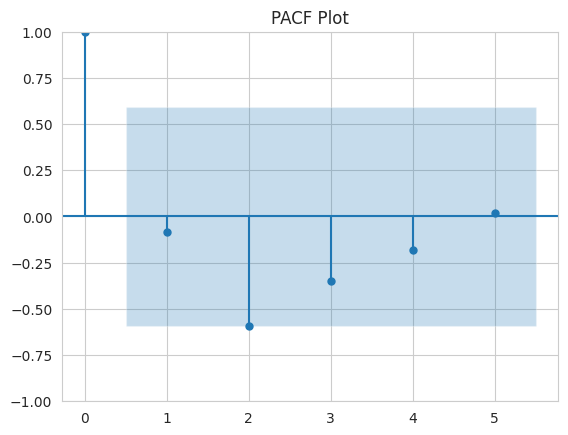

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(ts_diff2["total_kasus"])
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts_diff2["total_kasus"])
plt.title("PACF Plot")
plt.show()

# Split Data

In [ ]:
train = ts.loc[2013:2022]
test = ts.loc[2023:2025]

# Modeling

## Model Selection ARIMA

In [ ]:
import warnings
warnings.filterwarnings("ignore")

best_aic = float("inf")
best_order = None
best_model = None

for p in range(0,4):
    for d in range(0,3):
        for q in range(0,4):

            try:

                model = ARIMA(train["total_kasus"], order=(p,d,q))
                model_fit = model.fit()

                if model_fit.aic < best_aic:

                    best_aic = model_fit.aic
                    best_order = (p,d,q)
                    best_model = model_fit

            except:
                continue

print("Best ARIMA:", best_order)
print("Nilai AIC:", best_aic)

Best ARIMA: (0, 2, 1)
Nilai AIC: 56.528244965255084


In [ ]:
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:            total_kasus   No. Observations:                   10
Model:                 ARIMA(0, 2, 1)   Log Likelihood                 -26.264
Date:                Mon, 27 Apr 2026   AIC                             56.528
Time:                        01:32:50   BIC                             56.687
Sample:                             0   HQIC                            55.457
                                 - 10                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9995    347.923     -0.003      0.998    -682.917     680.918
sigma2        31.6316    1.1e+04      0.003      0.998   -2.15e+04    2.16e+04
Ljung-Box (L1) (Q):                   0.60   Jarque-

In [ ]:
arima_pred = best_model.forecast(steps=len(test))

## Model Linear Regression

In [ ]:
X_train = train.index.values.reshape(-1,1)
y_train = train["total_kasus"]

X_test = test.index.values.reshape(-1,1)

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Prediksi Model

In [ ]:
# Prediksi ARIMA
arima_pred = best_model.forecast(steps=len(test))

# Prediksi Linear Regression
lr_pred = lr.predict(X_test)

## Evaluasi Model

In [ ]:
def evaluate(actual, pred):

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)

    return rmse, mae

In [ ]:
arima_rmse, arima_mae = evaluate(test["total_kasus"], arima_pred)

lr_rmse, lr_mae = evaluate(test["total_kasus"], lr_pred)

print("ARIMA RMSE:", arima_rmse)
print("Linear RMSE:", lr_rmse)

ARIMA RMSE: 16.641674334728112
Linear RMSE: 20.376309788874906


## Compare Model

In [ ]:
model_compare = pd.DataFrame({
"Model":["ARIMA","Linear Regression"],
"RMSE":[arima_rmse, lr_rmse],
"MAE":[arima_mae, lr_mae]
})

print(model_compare)

               Model       RMSE        MAE
0              ARIMA  16.641674  16.444410
1  Linear Regression  20.376310  20.206061


Karena hasil RMSE dan MAE dari ARIMA lebih kecil, maka saya akan menggunakan ARIMA untuk proses selanjutnya

# ARIMA MODELING

## Walk-Forward Validation

In [ ]:
history = list(train["total_kasus"])
predictions = []

for t in range(len(test)):

    model = ARIMA(history, order=best_order)
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]

    predictions.append(yhat)

    history.append(test["total_kasus"].iloc[t])

## Evaluasi Walk-Forward

In [ ]:
rmse_walk = np.sqrt(mean_squared_error(test["total_kasus"], predictions))
mae_walk = mean_absolute_error(test["total_kasus"], predictions)

print("Walk-forward RMSE:", rmse_walk)
print("Walk-forward MAE:", mae_walk)

Walk-forward RMSE: 8.303110468363807
Walk-forward MAE: 6.907732408452252


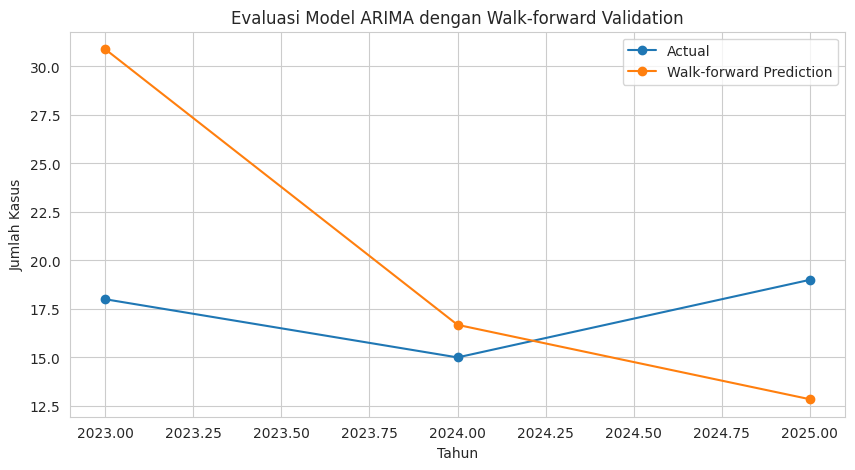

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(test.index, test["total_kasus"], label="Actual", marker="o")

plt.plot(test.index, predictions, label="Walk-forward Prediction", marker="o")

plt.title("Evaluasi Model ARIMA dengan Walk-forward Validation")

plt.xlabel("Tahun")
plt.ylabel("Jumlah Kasus")

plt.legend()

plt.show()

## Model Final

In [ ]:
model_final = ARIMA(ts["total_kasus"], order=best_order)
model_final_fit = model_final.fit()

## Prediksi

In [ ]:
evaluasi_df = pd.DataFrame({
"Tahun": test.index,
"Actual": test["total_kasus"].values,
"Prediction": predictions
})

print(evaluasi_df)

   Tahun  Actual  Prediction
0   2023      18   30.888872
1   2024      15   16.679576
2   2025      19   12.845251


In [ ]:
# Prediksi untuk SELURUH data (2013–2025)
fitted_values = model_final_fit.predict(start=0, end=len(ts)-1)

# Buat dataframe hasil
evaluasi_full = pd.DataFrame({
    "Tahun": ts.index,
    "Actual": ts["total_kasus"].values,
    "Prediction": fitted_values
})

print(evaluasi_full)

       Tahun  Actual  Prediction
tahun                           
2013    2013       2    0.000000
2014    2014       6    3.000001
2015    2015       8    9.999784
2016    2016      17   10.981551
2017    2017      22   22.108635
2018    2018      24   27.078106
2019    2019      19   28.334602
2020    2020      21   21.298412
2021    2021      33   23.237669
2022    2022      28   37.133490
2023    2023      18   30.415700
2024    2024      15   18.130958
2025    2025      19   14.563281


## Visualisasi Aktual vs Predict ARIMA

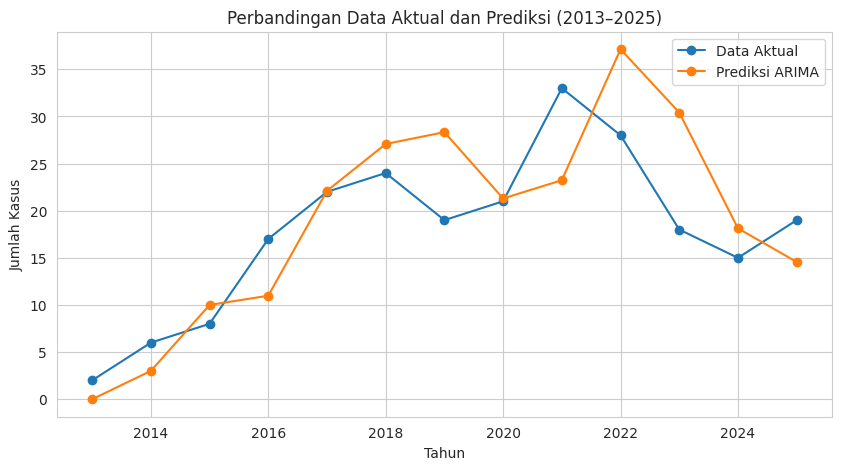

In [ ]:
# Plot
plt.figure(figsize=(10,5))

plt.plot(ts.index, ts["total_kasus"], label="Data Aktual", marker="o")
plt.plot(ts.index, fitted_values, label="Prediksi ARIMA", marker="o")

plt.title("Perbandingan Data Aktual dan Prediksi (2013–2025)")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Kasus")
plt.legend()

plt.show()

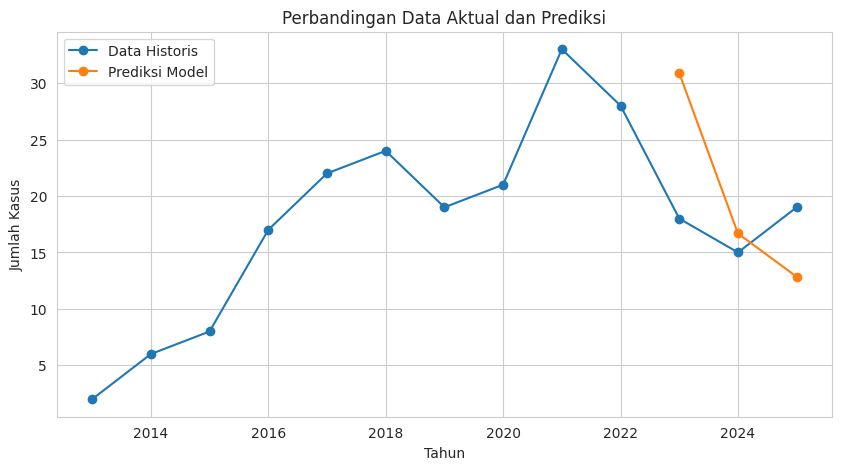

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(ts.index, ts["total_kasus"], label="Data Historis", marker="o")

plt.plot(evaluasi_df["Tahun"], evaluasi_df["Prediction"], label="Prediksi Model", marker="o")

plt.title("Perbandingan Data Aktual dan Prediksi")

plt.xlabel("Tahun")

plt.ylabel("Jumlah Kasus")

plt.legend()

plt.show()

# Forecast

In [ ]:
forecast_result = model_final_fit.get_forecast(steps=10)

forecast = forecast_result.predicted_mean

conf_int = forecast_result.conf_int()

tahun_prediksi = list(range(2026,2036))

prediksi_df = pd.DataFrame({
"Tahun":tahun_prediksi,
"Prediksi_Kasus":forecast.values,
"Batas_Bawah":conf_int.iloc[:,0].values,
"Batas_Atas":conf_int.iloc[:,1].values
})

rata_kasus = ts["total_kasus"].mean()

prediksi_df["Status_Risiko"] = prediksi_df["Prediksi_Kasus"].apply(
lambda x: "Tinggi" if x > rata_kasus else "Normal"
)

print(prediksi_df)

   Tahun  Prediksi_Kasus  Batas_Bawah  Batas_Atas Status_Risiko
0   2026       19.359633     6.398740   32.320525        Tinggi
1   2027       19.719265    -0.306459   39.744989        Tinggi
2   2028       20.078898    -6.557024   46.714819        Tinggi
3   2029       20.438530   -12.782706   53.659766        Tinggi
4   2030       20.798163   -19.125538   60.721863        Tinggi
5   2031       21.157795   -25.645668   67.961258        Tinggi
6   2032       21.517428   -32.371115   75.405970        Tinggi
7   2033       21.877060   -39.315032   83.069152        Tinggi
8   2034       22.236693   -46.482979   90.956364        Tinggi
9   2035       22.596325   -53.876389   99.069039        Tinggi


In [ ]:
rata_kasus = ts["total_kasus"].mean()

prediksi_df["Status_Risiko"] = prediksi_df["Prediksi_Kasus"].apply(
lambda x: "Tinggi" if x > rata_kasus else "Normal"
)

print(prediksi_df)

   Tahun  Prediksi_Kasus  Batas_Bawah  Batas_Atas Status_Risiko
0   2026       19.359633     6.398740   32.320525        Tinggi
1   2027       19.719265    -0.306459   39.744989        Tinggi
2   2028       20.078898    -6.557024   46.714819        Tinggi
3   2029       20.438530   -12.782706   53.659766        Tinggi
4   2030       20.798163   -19.125538   60.721863        Tinggi
5   2031       21.157795   -25.645668   67.961258        Tinggi
6   2032       21.517428   -32.371115   75.405970        Tinggi
7   2033       21.877060   -39.315032   83.069152        Tinggi
8   2034       22.236693   -46.482979   90.956364        Tinggi
9   2035       22.596325   -53.876389   99.069039        Tinggi


## Visualisasi Forecast

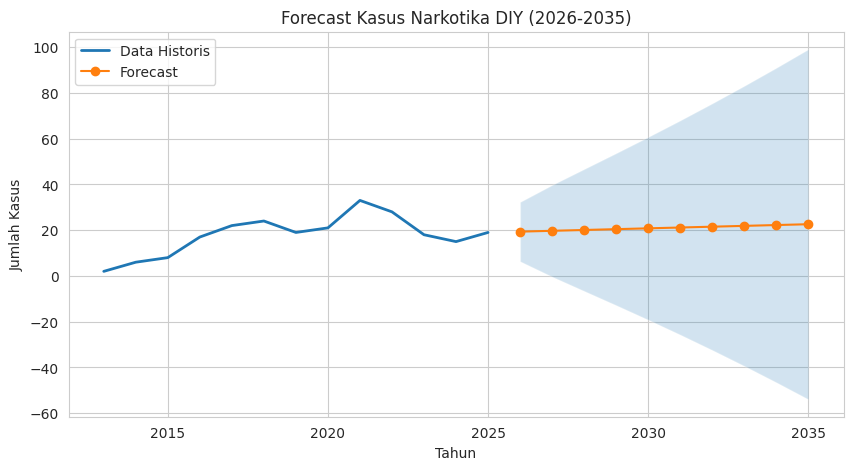

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(ts.index, ts["total_kasus"], label="Data Historis", linewidth=2)

plt.plot(tahun_prediksi, forecast, label="Forecast", marker="o")

plt.fill_between(
tahun_prediksi,
conf_int.iloc[:,0],
conf_int.iloc[:,1],
alpha=0.2
)

plt.title("Forecast Kasus Narkotika DIY (2026-2035)")

plt.xlabel("Tahun")
plt.ylabel("Jumlah Kasus")

plt.legend()

plt.show()